# Loading SQL Output Data

In [8]:
import pandas as pd
df=pd.read_csv(r'C:\Users\akash\Downloads\final_sql_output.csv')
df.head()

,sku,product_type,price,availability,number_of_products_sold,stock_levels,lead_time,supplier_name,transportation_modes,costs
0,SKU0,haircare,69.8080,55,802,58,29,Supplier 3,Road,187.752
1,SKU1,skincare,14.8435,95,736,53,23,Supplier 3,Road,503.066
2,SKU2,haircare,11.3197,34,8,1,12,Supplier 1,Air,141.920
3,SKU3,skincare,61.1633,68,83,23,24,Supplier 5,Rail,254.776
4,SKU4,skincare,4.8055,26,871,5,5,Supplier 1,Air,923.441


# Understand the Data

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sku                      100 non-null    str    
 1   product_type             100 non-null    str    
 2   price                    100 non-null    float64
 3   availability             100 non-null    int64  
 4   number_of_products_sold  100 non-null    int64  
 5   stock_levels             100 non-null    int64  
 6   lead_time                100 non-null    int64  
 7   supplier_name            100 non-null    str    
 8   transportation_modes     100 non-null    str    
 9   costs                    100 non-null    float64
dtypes: float64(2), int64(4), str(4)
memory usage: 7.9 KB


In [12]:
df.describe()

,price,availability,number_of_products_sold,stock_levels,lead_time,costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.462457,48.400000,460.990000,47.770000,17.080000,529.245730
std,31.168191,30.743317,303.780074,31.369372,8.846251,258.301686
min,1.699980,1.000000,8.000000,0.000000,1.000000,103.916000
25%,19.597825,22.750000,184.250000,16.750000,10.000000,318.778750
50%,51.239850,43.500000,392.500000,47.500000,18.000000,520.430500
75%,77.198225,75.000000,704.250000,73.000000,25.000000,763.078000
max,99.171300,100.000000,996.000000,100.000000,30.000000,997.413000


# Data Cleaning
# Handle Missing Values

In [13]:
df.isnull().sum()

sku                        0
product_type               0
price                      0
availability               0
number_of_products_sold    0
stock_levels               0
lead_time                  0
supplier_name              0
transportation_modes       0
costs                      0
dtype: int64

In [15]:
df["price"]=df["price"].fillna(df["price"].median())
df["stock_levels"]=df["stock_levels"].ffill()
df["number_of_products_sold "]=df["number_of_products_sold"].fillna(0)

# Removes Duplicates

In [21]:
df.drop_duplicates(inplace=True)

# Fix Invalid Values

In [22]:
df=df[df["number_of_products_sold"]>=0]
df=df[df["stock_levels"]>=0]

# Sales Distribution

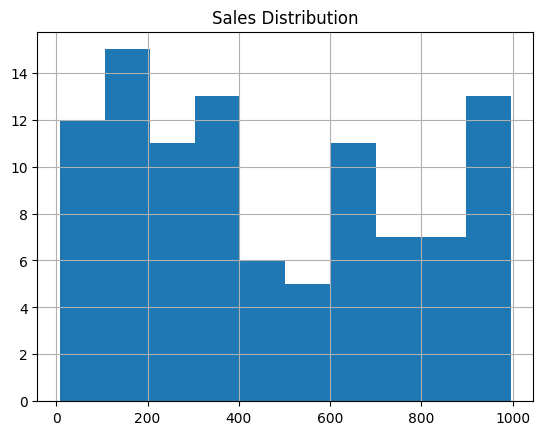

In [10]:
import matplotlib.pyplot as plt
df["number_of_products_sold"].hist()
plt.title("Sales Distribution")
plt.show()

# Stock Distribution


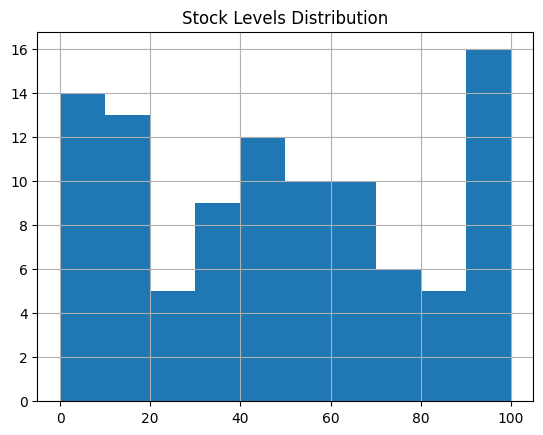

In [24]:
df["stock_levels"].hist()
plt.title("Stock Levels Distribution")
plt.show()

# Sales vs Stock

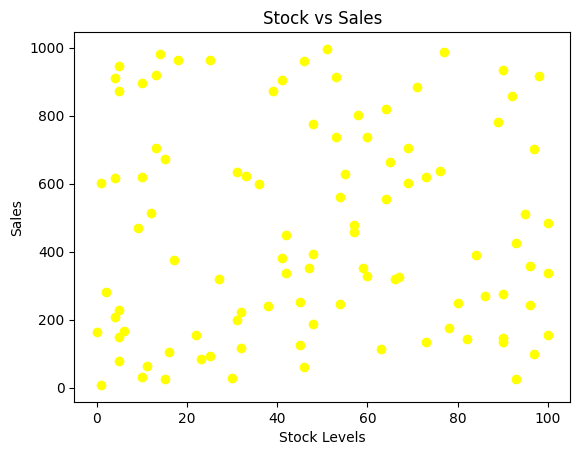

In [25]:
plt.scatter(df["stock_levels"],df["number_of_products_sold"],color="yellow")
plt.xlabel("Stock Levels")
plt.ylabel("Sales")
plt.title("Stock vs Sales")
plt.show()

# Price vs Sales

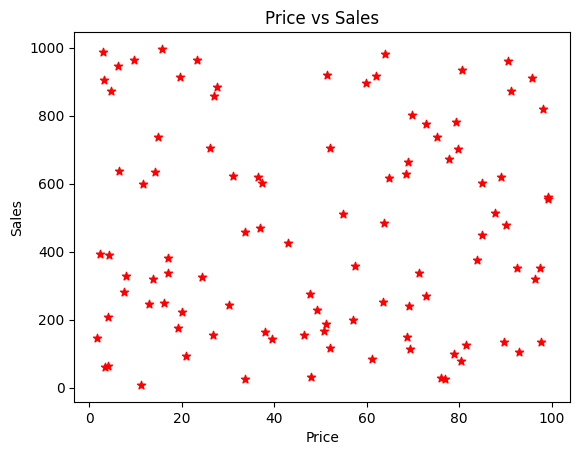

In [26]:
plt.scatter(df["price"],df["number_of_products_sold"],color="red",marker="*")
plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")
plt.show()


# Create Overstock and Stockout Flags

In [40]:
df["overstock"]=df["stock_levels"]>(df["number_of_products_sold"] * 1.5 )
df["stockout_risk"]=df["stock_levels"]<df["number_of_products_sold"]

#  Lead Time Analysis

In [13]:
import numpy as np
import pandas as pd
df=pd.read_csv(r'C:\Users\akash\Downloads\final_sql_output.csv')
df["delay_days"] = np.random.randint(0,4,size=len(df))
df["effective_lead_time"]=df["lead_time"] + df["delay_days"]

# Top Selling Products

In [38]:
df.groupby("sku")["number_of_products_sold"].sum().sort_values(ascending=False).head()

sku
SKU10    996
SKU94    987
SKU9     980
SKU37    963
SKU36    963
Name: number_of_products_sold, dtype: int64

# High Overstock Products


In [43]:
df[df["overstock"]==True]

,sku,product_type,price,availability,number_of_products_sold,stock_levels,lead_time,supplier_name,transportation_modes,costs,delay_days,effective_lead_time,overstock,stockout_risk
45,SKU45,haircare,33.7841,1,24,93,25,Supplier 2,Rail,495.306,1,26,True,False


# Stockout Risk Products


In [44]:
df[df["stockout_risk"]==True]

,sku,product_type,price,availability,number_of_products_sold,stock_levels,lead_time,supplier_name,transportation_modes,costs,delay_days,effective_lead_time,overstock,stockout_risk
0,SKU0,haircare,69.80800,55,802,58,29,Supplier 3,Road,187.752,1,30,False,True
1,SKU1,skincare,14.84350,95,736,53,23,Supplier 3,Road,503.066,1,24,False,True
2,SKU2,haircare,11.31970,34,8,1,12,Supplier 1,Air,141.920,0,12,False,True
3,SKU3,skincare,61.16330,68,83,23,24,Supplier 5,Rail,254.776,0,24,False,True
4,SKU4,skincare,4.80550,26,871,5,5,Supplier 1,Air,923.441,2,7,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SKU95,haircare,77.90390,65,672,15,18,Supplier 4,Air,778.864,3,21,False,True
96,SKU96,cosmetics,24.42310,29,324,67,28,Supplier 3,Road,188.742,1,29,False,True
97,SKU97,haircare,3.52611,56,62,46,10,Supplier 4,Road,540.132,1,11,False,True
98,SKU98,skincare,19.75460,43,913,53,28,Supplier 5,Rail,882.199,1,29,False,True


# Supplier Performance

# Sales by Product

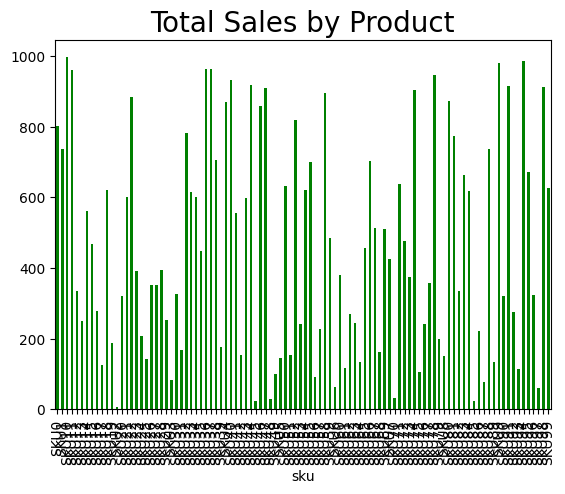

In [18]:
df.groupby("sku")["number_of_products_sold"].sum().plot(kind='bar',color="green")
plt.title("Total Sales by Product",fontsize=20)
plt.show()

# Supplier Performance

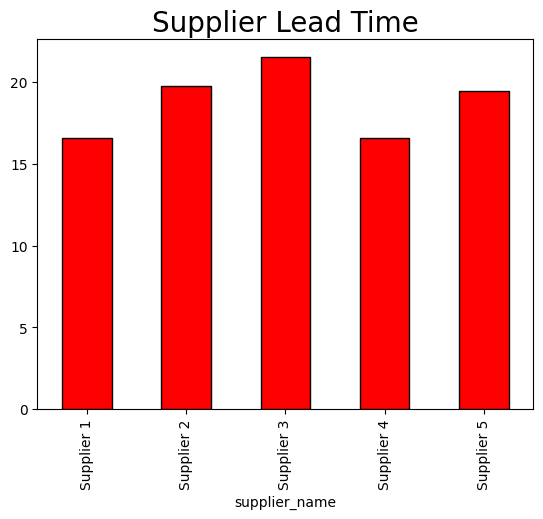

In [19]:
df.groupby("supplier_name") ["effective_lead_time"].mean().plot(kind="bar",color="red",edgecolor="black")
plt.title("Supplier Lead Time",fontsize=20)
plt.show()

# Save Clean Data

In [20]:
df.to_csv("cleaned_data.csv",index=False)